In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image, PIL.ImageDraw, PIL.ImageFont
import tensorflow as tf
import tensorflow_datasets as tfds

in_width = 75
in_height = 75
use_normalised_cordinates = True


In [2]:
def draw_bounding_boxes_on_image_array(image, boxes, colors, thickness=1, display_str_list=()):
    image_pil = PIL.Image.fromarray(image)
    rgbimg = PIL.Image.new("RGBA", image_pil.size)
    rgbimg.paste(image_pil)
    draw_bounding_boxes_on_image(rgbimg, boxes, colors, thickness=thickness, display_str_lists=display_str_list)
    return np.array(rgbimg)

def draw_bounding_boxes_on_image(image, boxes, colors, thickness=1, display_str_lists=()):
    boxes_shape = boxes.shape
    if not boxes_shape:
        return
    if len(boxes_shape) != 2 or boxes_shape[1] != 4:
        raise ValueError('Input must be of size [N, 4]')
    for i in range(boxes_shape[0]):
        draw_bounding_box_on_image(image, boxes[i, 1], boxes[i, 0], boxes[i, 3], boxes[i, 2],
                                   colors[i], thickness=3,
                                   display_str_list=[display_str_lists[i]])

def draw_bounding_box_on_image(image, ymin, xmin, ymax, xmax, color='red', thickness=1,
                                use_normalised_coordinates=True, display_str_list=()):
    draw = PIL.ImageDraw.Draw(image)
    im_width, im_height = image.size
    if use_normalised_coordinates:
        (left, right, top, bottom) = (xmin * im_width, xmax * im_width,
                                      ymin * im_height, ymax * im_height)
    else:
        (left, right, top, bottom) = (xmin, xmax, ymin, ymax)
    draw.line([(left, top), (left, bottom), (right, bottom), (right, top),
               (left, top)], width=thickness, fill=color)


In [3]:
def dataset_to_numpy_util(training_dataset, validation_dataset, N):
    batch_train_ds = training_dataset.unbatch().batch(N)

    if tf.executing_eagerly():
        for validation_digits, (validation_labels, validation_boxes) in validation_dataset:
            validation_digits = validation_digits.numpy()
            validation_labels = validation_labels.numpy()
            validation_boxes  = validation_boxes.numpy()
            break
        for training_digits, (training_labels, training_boxes) in batch_train_ds:
            training_digits = training_digits.numpy()
            training_labels = training_labels.numpy()
            training_boxes  = training_boxes.numpy()
            break

    validation_labels = np.argmax(validation_labels, axis=1)
    training_labels   = np.argmax(training_labels,   axis=1)
    return (training_digits, training_labels, training_boxes,
            validation_digits, validation_labels, validation_boxes)


In [4]:
MATPLOTLIB_FONT_DIR = os.path.join(os.path.dirname(plt.__file__), "mpl-data/fonts/ttf")

def create_digits_from_local_fonts(n):
    font_labels = []
    img   = PIL.Image.new('LA', (75 * n, 75), color=(0, 255))
    font1 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, "DejaVuSansMono-Oblique.ttf"), 25)
    font2 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, "DejaVuSansMono-Bold.ttf"),    25)
    d = PIL.ImageDraw.Draw(img)
    for i in range(n):
        font_labels.append(i % 10)
        d.text((7 + i * 75, 0 if i < 10 else -4), str(i % 10), fill=(255, 255),
               font=font1 if i < 10 else font2)
    font_digits = np.array(img.getdata(), np.float32)[:, 0] / 255.0
    font_digits = np.reshape(
        np.stack(np.split(np.reshape(font_digits, [75, 75 * n]), n, axis=1), axis=0),
        [n, 75 * 75])
    return font_digits, font_labels

def display_digits_with_boxes(digits, predictions, labels, pred_bboxes, bboxes, iou, title):
    n       = 10
    indexes = np.random.choice(len(predictions), size=n)
    n_digits      = digits[indexes]
    n_predictions = predictions[indexes]
    n_labels      = labels[indexes]

    n_iou = []
    if len(iou) > 0:
        n_iou = iou[indexes]

    if len(pred_bboxes) > 0:
        n_pred_bboxes = pred_bboxes[indexes]
    if len(bboxes) > 0:
        n_bboxes = bboxes[indexes]

    n_digits = n_digits * 255.0
    n_digits = n_digits.reshape(n, 75, 75)
    fig = plt.figure(figsize=(20, 4))
    plt.title(title)
    plt.xticks([])
    plt.yticks([])

    for i in range(10):
        ax = fig.add_subplot(1, 10, i + 1)
        bboxes_to_plot = []
        if len(pred_bboxes) > i:
            bboxes_to_plot.append(n_pred_bboxes[i])
        if len(bboxes) > i:
            bboxes_to_plot.append(n_bboxes[i])

        img_to_draw = draw_bounding_boxes_on_image_array(
            image=n_digits[i],
            boxes=np.asarray(bboxes_to_plot),
            colors=['green', 'red'],           # fixed: green=pred, red=true
            display_str_list=["Pred", "True"]  # fixed: match color order
        )

        plt.xlabel(n_predictions[i])
        plt.xticks([])
        plt.yticks([])

        if n_predictions[i] != n_labels[i]:
            ax.xaxis.label.set_color('red')

        plt.imshow(img_to_draw)

        if len(n_iou) > i:
            color = "black"
            if n_iou[i][0] < iou_threshold:
                color = "red"
            ax.text(0.2, -0.3, "iou: %s" % (n_iou[i][0]), color=color, transform=ax.transAxes)


In [5]:
def plot_metrics(metric_name, title):
    plt.title(title)
    plt.plot(history.history[metric_name],             color='blue',  label=metric_name)
    plt.plot(history.history['val_' + metric_name],    color='green', label='val_' + metric_name)
    plt.legend()
    plt.show()


In [6]:
strategy   = tf.distribute.get_strategy()
print("Replicas:", strategy.num_replicas_in_sync)

BATCH_SIZE = 64

def read_image_tfds(image, label):
    xmin = tf.random.uniform((), 0, 48, dtype=tf.int32)
    ymin = tf.random.uniform((), 0, 48, dtype=tf.int32)
    image = tf.reshape(image, (28, 28, 1,))
    image = tf.image.pad_to_bounding_box(image, ymin, xmin, 75, 75)
    image = tf.cast(image, tf.float32) / 255.0
    xmin  = tf.cast(xmin, tf.float32)
    ymin  = tf.cast(ymin, tf.float32)
    xmax  = (xmin + 28) / 75
    ymax  = (ymin + 28) / 75
    xmin  = xmin / 75
    ymin  = ymin / 75
    return image, (tf.one_hot(label, 10), [xmin, ymin, xmax, ymax])

def get_training_dataset():
    with strategy.scope():
        dataset = tfds.load("mnist", split="train", as_supervised=True)
        dataset = dataset.map(read_image_tfds, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(5000, reshuffle_each_iteration=True)
        dataset = dataset.repeat()
        dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        return dataset

def get_validation_dataset():
    with strategy.scope():
        dataset = tfds.load("mnist", split="test", as_supervised=True)
        dataset = dataset.map(read_image_tfds, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(10000, drop_remainder=True)
        dataset = dataset.repeat()
        return dataset

with strategy.scope():
    training_dataset   = get_training_dataset()
    validation_dataset = get_validation_dataset()


Replicas: 1


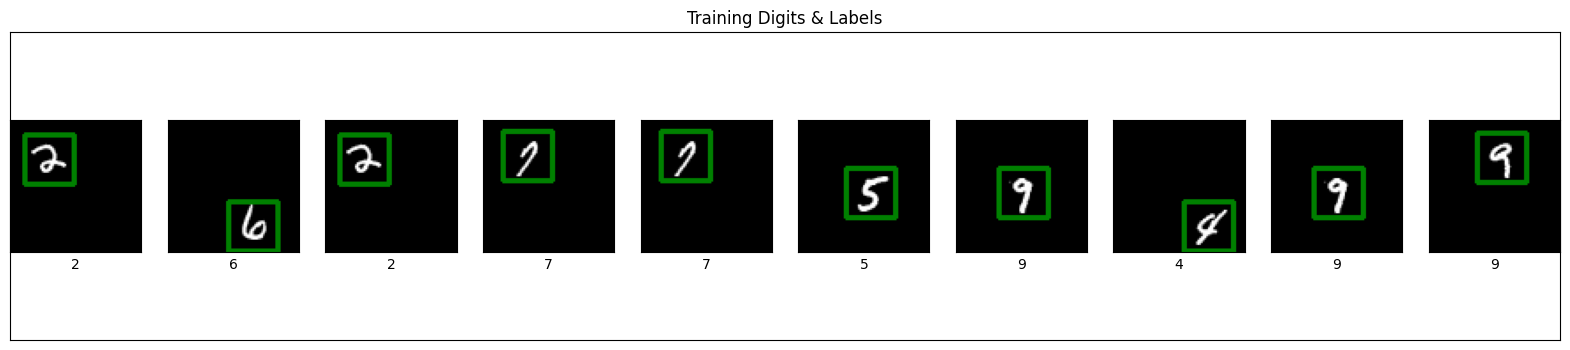

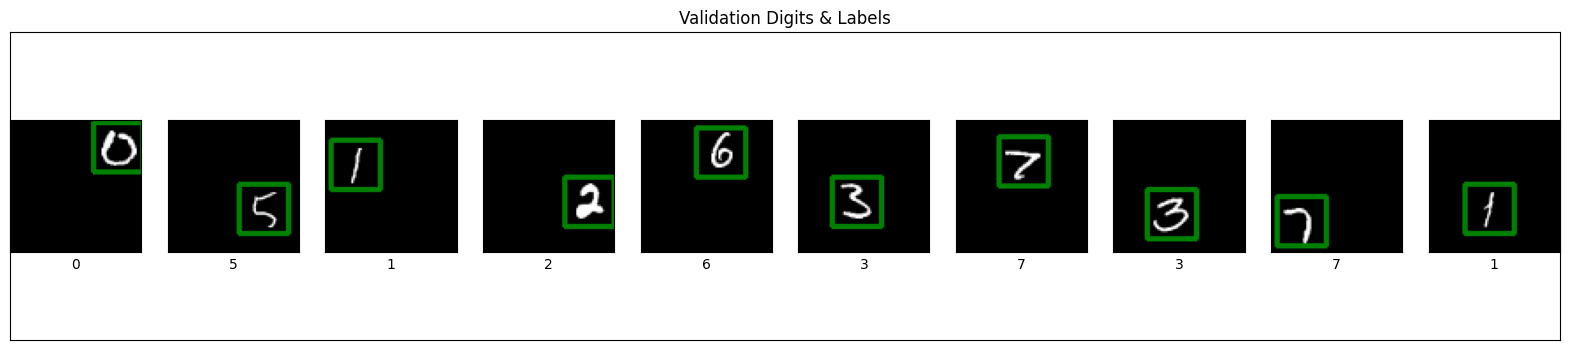

In [7]:
(training_digits, training_labels, training_bboxes,
 validation_digits, validation_labels, validation_bboxes) = dataset_to_numpy_util(
    training_dataset, validation_dataset, 10)

display_digits_with_boxes(training_digits, training_labels, training_labels,
                          np.array([]), training_bboxes, np.array([]),
                          "Training Digits & Labels")
plt.show()

display_digits_with_boxes(validation_digits, validation_labels, validation_labels,
                          np.array([]), validation_bboxes, np.array([]),
                          "Validation Digits & Labels")
plt.show()


In [8]:
def feature_extractor(inputs):
    x = tf.keras.layers.Conv2D(16, activation='relu', kernel_size=3, input_shape=(75, 75, 1))(inputs)
    x = tf.keras.layers.AveragePooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(32, activation='relu', kernel_size=3)(x)
    x = tf.keras.layers.AveragePooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(64, activation='relu', kernel_size=3)(x)
    x = tf.keras.layers.AveragePooling2D((2, 2))(x)
    return x

def dense_layers(inputs):
    x = tf.keras.layers.Flatten()(inputs)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    return x

def classifier(inputs):
    return tf.keras.layers.Dense(10, activation="softmax", name="classification")(inputs)

def bounding_box_regression(inputs):
    return tf.keras.layers.Dense(4, name="bounding_box")(inputs)

def final_model(inputs):
    feature_cnn   = feature_extractor(inputs)
    dense_output  = dense_layers(feature_cnn)
    classification_output  = classifier(dense_output)
    bounding_box_output    = bounding_box_regression(dense_output)
    model = tf.keras.Model(inputs=inputs,
                           outputs=[classification_output, bounding_box_output])
    return model

def define_and_compile_model(inputs):
    model = final_model(inputs)
    model.compile(optimizer='adam',
                  loss={'classification': 'categorical_crossentropy',
                        'bounding_box':   'mse'},
                  metrics={'classification': 'accuracy',
                           'bounding_box':   'mse'})
    return model

with strategy.scope():
    inputs = tf.keras.layers.Input(shape=(75, 75, 1,))
    model  = define_and_compile_model(inputs)
    model.summary()


C:\Users\SOHAM\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 75, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 73, 73,    │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 36, 36,    │          0 │ conv2d[0][0]      │
│ (AveragePooling2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 34, 34,    │      4,640 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 17, 17,    │          0 │ conv2d_1[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 15, 15,    │     18,496 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 7, 7, 64)  │          0 │ conv2d_2[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 10)        │      1,290 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bounding_box        │ (None, 4)         │        516 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 426,638 (1.63 MB)

 Trainable params: 426,638 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
EPOCHS          = 20
steps_per_epoch = 60000 // BATCH_SIZE

history = model.fit(training_dataset,
                    steps_per_epoch=steps_per_epoch,
                    validation_data=validation_dataset,
                    validation_steps=1,
                    epochs=EPOCHS)


Epoch 1/20
937/937 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - bounding_box_loss: 0.0147 - bounding_box_mse: 0.0147 - classification_accuracy: 0.6524 - classification_loss: 0.9906 - loss: 1.0053 - val_bounding_box_loss: 0.0075 - val_bounding_box_mse: 0.0075 - val_classification_accuracy: 0.9200 - val_classification_loss: 0.2693 - val_loss: 0.2768
Epoch 2/20
937/937 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - bounding_box_loss: 0.0058 - bounding_box_mse: 0.0058 - classification_accuracy: 0.9216 - classification_loss: 0.2557 - loss: 0.2615 - val_bounding_box_loss: 0.0039 - val_bounding_box_mse: 0.0039 - val_classification_accuracy: 0.9494 - val_classification_loss: 0.1640 - val_loss: 0.1679
Epoch 3/20
937/937 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - bounding_box_loss: 0.0035 - bounding_box_mse: 0.0035 - classification_accuracy: 0.9447 - classification_loss: 0.1831 - loss: 0.1865 - val_bounding_box_loss: 0.0030 - val_bounding_box_mse: 0.0030 - val_classification_accuracy: 0.9633 - val_classification_loss: 

KeyboardInterrupt: 

In [ ]:
loss, classification_loss, bounding_box_loss, classification_acc, bounding_box_mse = \
    model.evaluate(validation_dataset, steps=1)

print("\n-------------------------------------")
print("Validation Accuracy: ", classification_acc)
print("-------------------------------------\n")

# Print actual history keys so we know exact metric names
print("History keys:", list(history.history.keys()))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - bounding_box_loss: 0.0011 - bounding_box_mse: 0.0011 - classification_accuracy: 0.9882 - classification_loss: 0.0387 - loss: 0.0397

-------------------------------------
Validation Accuracy:  0.0010507232509553432
-------------------------------------

History keys: ['bounding_box_loss', 'bounding_box_mse', 'classification_accuracy', 'classification_loss', 'loss', 'val_bounding_box_loss', 'val_bounding_box_mse', 'val_classification_accuracy', 'val_classification_loss', 'val_loss']


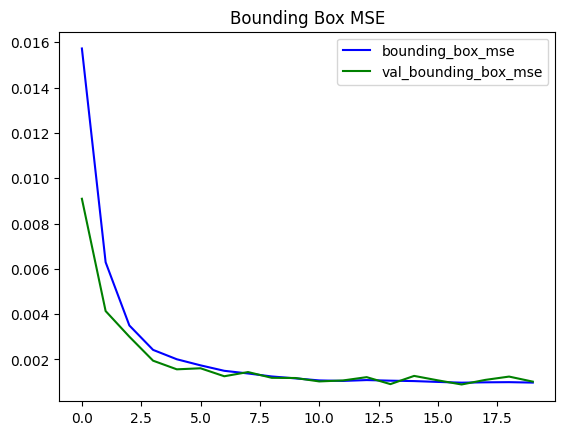

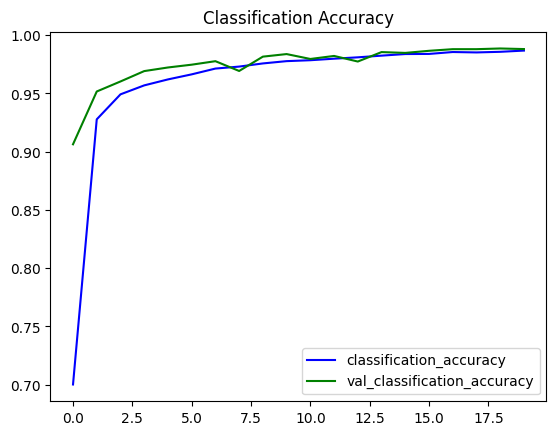

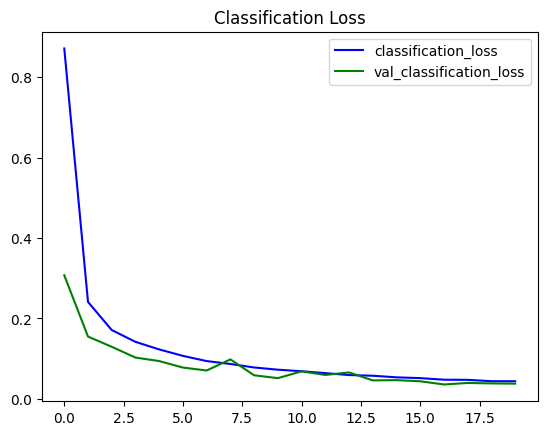

In [ ]:
# fixed metric key names to match what Keras actually logs
plot_metrics("bounding_box_mse",          "Bounding Box MSE")
plot_metrics("classification_accuracy",   "Classification Accuracy")
plot_metrics("classification_loss",       "Classification Loss")


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


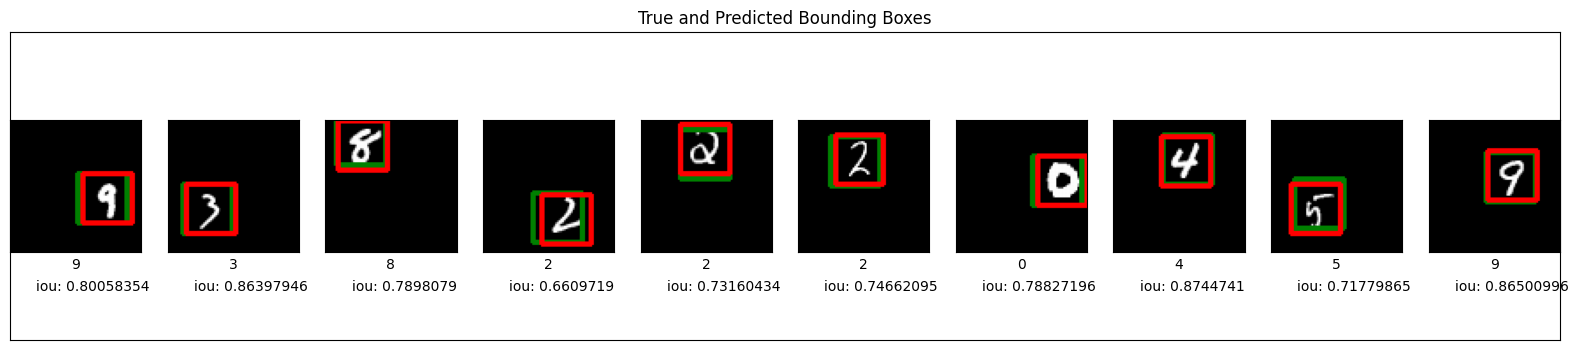

In [ ]:
def intersection_over_union(pred_box, true_box):
    xmin_pred, ymin_pred, xmax_pred, ymax_pred = np.split(pred_box, 4, axis=1)
    xmin_true, ymin_true, xmax_true, ymax_true = np.split(true_box, 4, axis=1)

    smoothing_factor = 1e-10

    xmin_overlap = np.maximum(xmin_pred, xmin_true)
    xmax_overlap = np.minimum(xmax_pred, xmax_true)
    ymin_overlap = np.maximum(ymin_pred, ymin_true)
    ymax_overlap = np.minimum(ymax_pred, ymax_true)

    pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)

    overlap_area = (np.maximum((xmax_overlap - xmin_overlap), 0) *
                    np.maximum((ymax_overlap - ymin_overlap), 0))
    union_area   = (pred_box_area + true_box_area) - overlap_area

    iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)
    return iou

iou_threshold = 0.6

prediction       = model.predict(validation_digits, batch_size=64)
predicted_labels = np.argmax(prediction[0], axis=1)
prediction_bboxes = prediction[1]

iou = intersection_over_union(prediction_bboxes, validation_bboxes)

display_digits_with_boxes(validation_digits, predicted_labels, validation_labels,
                          prediction_bboxes, validation_bboxes, iou,
                          "True and Predicted Bounding Boxes")
plt.show()
